## OUTLIERS (DIFFRENT TYPE OF OUTLIERS)
1. Graphical Methods — look at it visually

Boxplot — draws a box, anything floating outside as a dot = outlier
Histogram — bar chart of your data, lone bars far away = outlier
Scatterplot — plot two columns against each other, lone dots far from the crowd = outlier


2. Statistical Methods — use math to find them

Z-Score — measures how far a point is from the average. Use this when your data is a normal bell curve shape
IQR (Interquartile Range) — looks at the middle 50% of data, flags anything too far outside. Use this when data is skewed (most real data)


3. Machine Learning Techniques — let algorithms find them

Isolation Forest — builds random decision trees, points that get separated quickly = outliers
DBSCAN — groups data into clusters, points that don't belong to any cluster = outliers
Clustering algorithms — same idea, find points that sit alone away from groups

In [49]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\weightHeight.csv')
df.head(20)
df3=df.copy()
df4=df.copy()

In [9]:
df.columns

Index(['Unnamed: 0', 'Weight (kg)', 'Standing Height (cm)', 'BMI(kg/m**2)'], dtype='object')

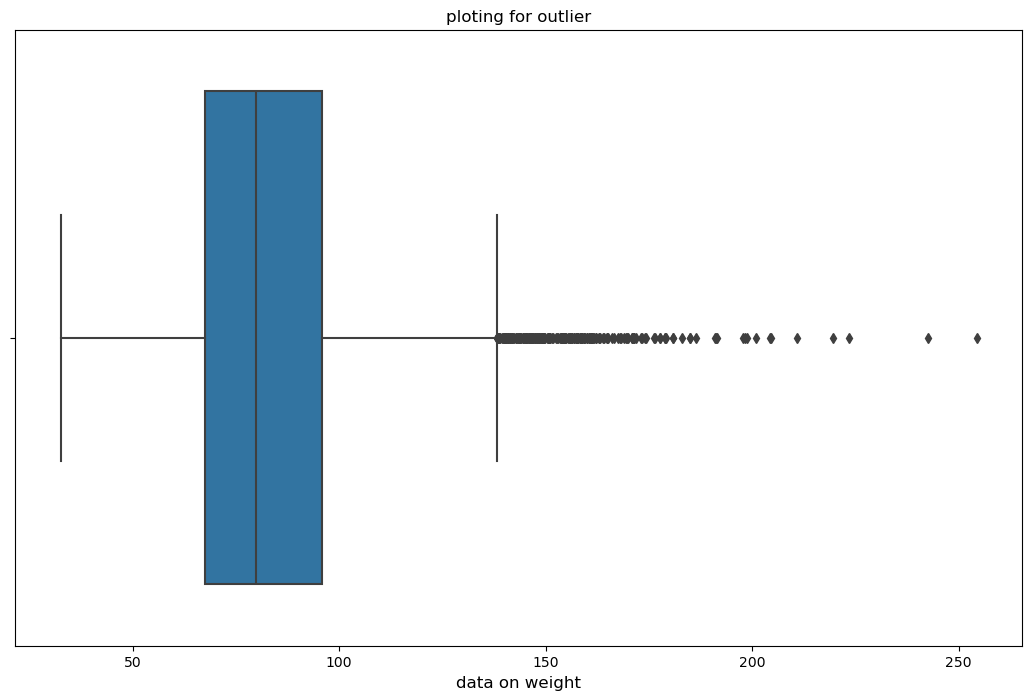

In [18]:
plt.figure(figsize=(13,8))
sns.boxplot(x=df['Weight (kg)'])

plt.title("ploting for outlier",fontsize=12)
plt.xlabel("data on weight",fontsize=12)
plt.show()

C:\Users\Dhruv stark\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


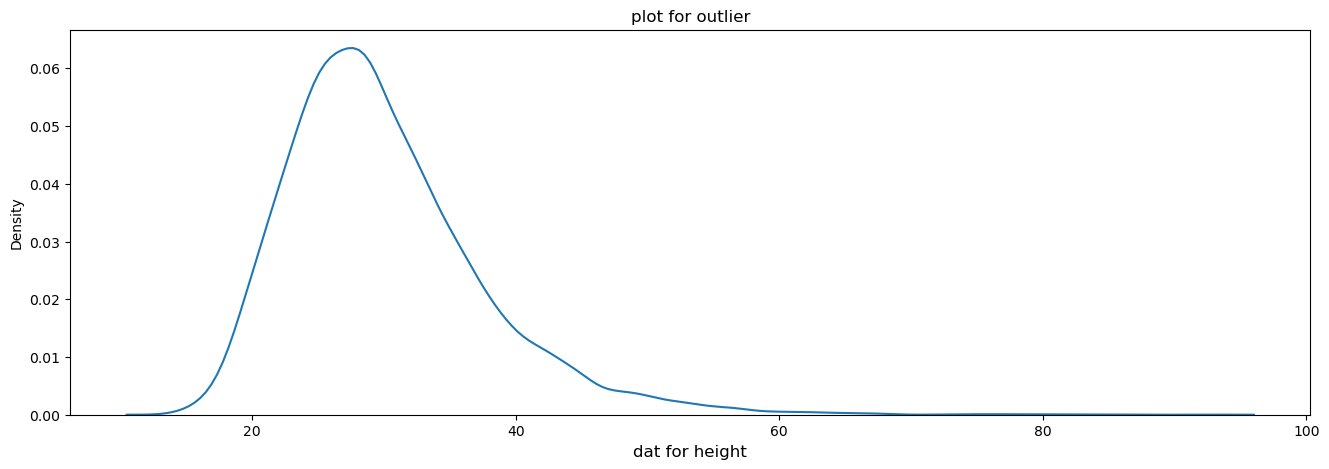

In [29]:
plt.figure(figsize=(16,5))
sns.kdeplot(x=df["BMI(kg/m**2)"])

plt.title("plot for outlier",fontsize = 12)
plt.xlabel("dat for height",fontsize=12)
plt.show()

In [22]:
df.skew()

Unnamed: 0              0.000000
Weight (kg)             1.129603
Standing Height (cm)    0.142496
BMI(kg/m**2)            1.353043
dtype: float64

## if data skewed <1.0 or >1.0 than we should go for the IQR inter quartile range 
if its normal between 0 to 1 than we have to use z score for 
## THESE ALL ARE FOR SMALL DATASETS 

In [23]:
from scipy import stats
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
z_scoreheight = stats.zscore(df["Standing Height (cm)"])
z_scoreheight

0      -0.639108
1       1.553698
2       1.742220
3       1.851364
4       1.037744
          ...   
8383    1.206421
8384   -1.869460
8385    0.204279
8386    0.968288
8387    0.085213
Name: Standing Height (cm), Length: 8388, dtype: float64

C:\Users\Dhruv stark\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


KeyError: 'z_scoreheight'

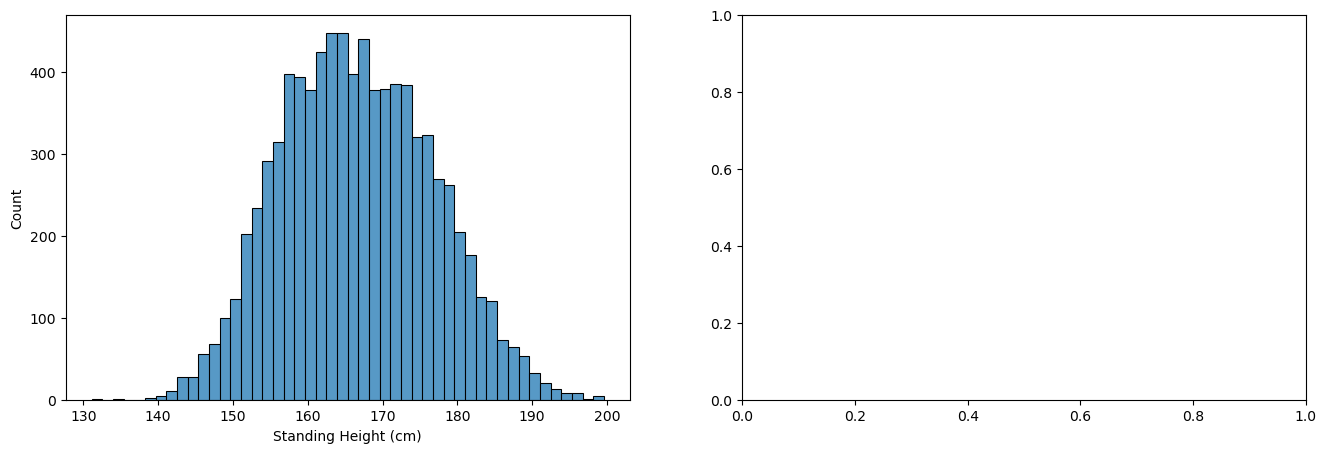

In [66]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df["Standing Height (cm)"])

plt.subplot(1,2,2)
sns.histplot(df["z_scoreheight"])
plt.show()

## Step 1 — Calculate IQR
Split your data into 4 equal parts. Q1 is the end of the first part, Q3 is the end of the third part. IQR = Q3 minus Q1. This gives you the range of the middle 50% of your data.

Step 2 — Find the Boundaries
Now calculate a safe zone:

Lower boundary = Q1 minus 1.5 times IQR
Upper boundary = Q3 plus 1.5 times IQR

Anything outside this zone is suspicious.

Step 3 — Flag the Outliers
Any row where the value is below the lower boundary or above the upper boundary = outlier.


In [7]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,9))
sns.boxplot(x=df["Weight (kg)"])
plt.xlabel("iqr for the outlier",fontsize=12)
plt.show()

NameError: name 'df' is not defined

<Figure size 1200x900 with 0 Axes>

In [8]:
plt.figure(figsize=(13,8))
sns.boxplot(x=df['Weight (kg)'])

plt.title("ploting for outlier",fontsize=12)
plt.xlabel("data on weight",fontsize=12)
plt.show()

NameError: name 'df' is not defined

<Figure size 1300x800 with 0 Axes>

In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\weightHeight.csv')
df.head(20)

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6
5,5,91.1,152.7,39.1
6,6,72.6,158.4,28.9
7,7,73.0,161.2,28.1
8,8,81.4,161.3,31.3
9,9,86.0,167.8,30.5


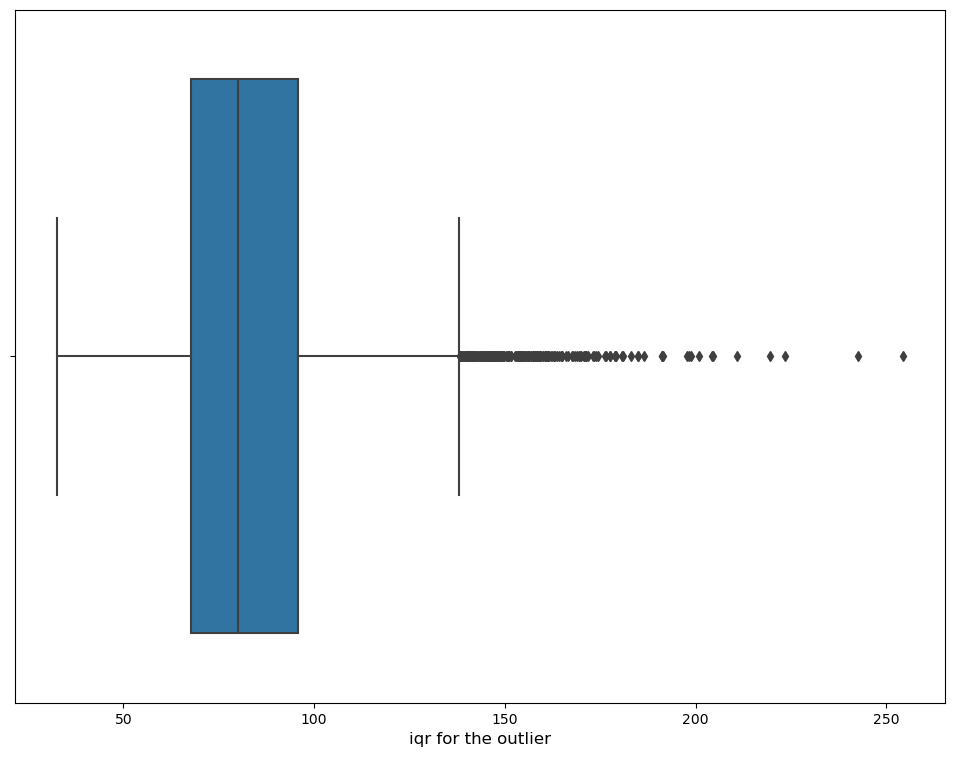

In [11]:
plt.figure(figsize=(12,9))
sns.boxplot(x=df["Weight (kg)"])
plt.xlabel("iqr for the outlier",fontsize=12)
plt.show()

In [12]:
df["Weight (kg)"].describe()

count    8388.000000
mean       83.669218
std        23.171638
min        32.600000
25%        67.600000
50%        79.900000
75%        95.800000
max       254.300000
Name: Weight (kg), dtype: float64

In [16]:
q1 = df["Weight (kg)"].quantile(0.25)
q3 = df["Weight (kg)"].quantile(0.75)
iqr = q3-q1 
iqr


28.200000000000003

In [20]:
manimum = q1 - 1.5*(iqr)
maximum = q3 + 1.5*(iqr)
manimum,maximum 

(25.29999999999999, 138.1)

In [21]:
df[(df["Weight (kg)"]<manimum)|(df["Weight (kg)"]>maximum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4


## Step 5 — Documentation (most beginners skip this)
Professionals write exactly what they did and why:
Column          : Item_Outlet_Sales
Outliers found  : 207 rows × 4 columns
Method used     : IQR
Decision        : Winsorizati on at 99th percentile
Reason          : Extreme sales are valid but distort model
                  Business confirmed no data errors

First observation — BMI values are alarming
Normal BMI range:  18.5 – 24.9
Overweight:        25.0 – 29.9
Obese:             30.0+

Your data:
Row 34   → BMI 46.2  ← severely obese
Row 36   → BMI 55.1  ← extremely obese
Row 94   → BMI 61.9  ← dangerously high
Row 86   → BMI 43.3  ← severely obese
Every single row shown is a BMI outlier. This means your IQR correctly flagged these.

But now apply domain knowledge
Weight 138kg at 172cm → BMI 46  → medically possible ✅
Weight 191kg at 175cm → BMI 61  → extremely rare but possible ✅
Weight 174kg at 190cm → BMI 48  → possible ✅
None of these are data entry errors. These are real obese people in the dataset.

Professional decision here
OptionShould you do it?
Remove these rows❌ No — real valid dataCap 
the BMI❌ No — distorts medical meaningKeep them✅ 
YesLog transform BMI✅ Maybe — reduces skew for model

## cap and floor (wesorization)
using the clip method

In [22]:
manimum,maximum


(25.29999999999999, 138.1)

In [29]:
upper = maximum 
lower = manimum

df["Weight (kg)"]=df["Weight (kg)"].clip(lower,upper)
df.describe()

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
count,8388.000000,8388.000000,8388.000000,8388.000000
mean,4193.500000,83.177992,166.641190,30.034859
std,2421.551362,21.565901,10.079013,7.565376
min,0.000000,32.600000,131.100000,14.200000
25%,2096.750000,67.600000,159.100000,24.900000
50%,4193.500000,79.900000,166.200000,28.800000
75%,6290.250000,95.800000,173.900000,33.800000
max,8387.000000,138.100000,199.600000,92.300000


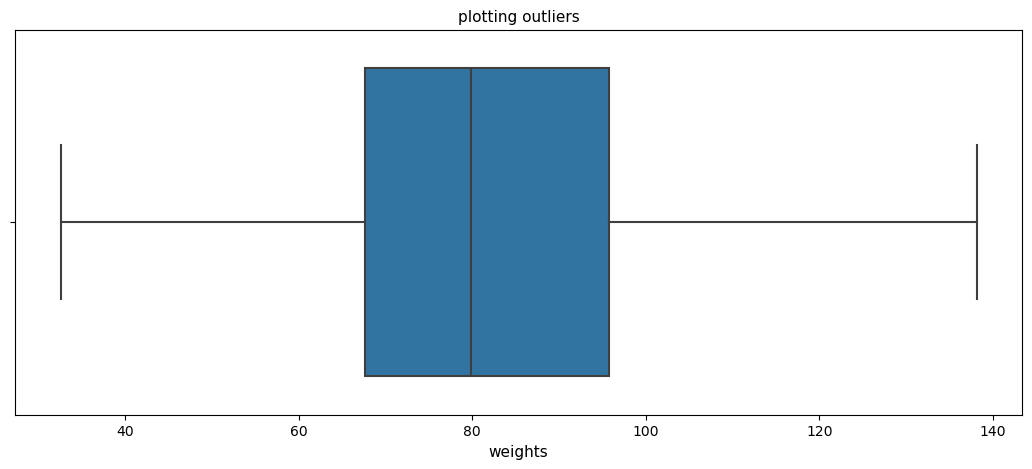

In [39]:
plt.figure(figsize=(13,5))
sns.boxplot(x=df["Weight (kg)"])
plt.title("plotting outliers",fontsize=11)
plt.xlabel("weights",fontsize=11)
plt.show()

Max after clip: 138.1
Min after clip: 32.6


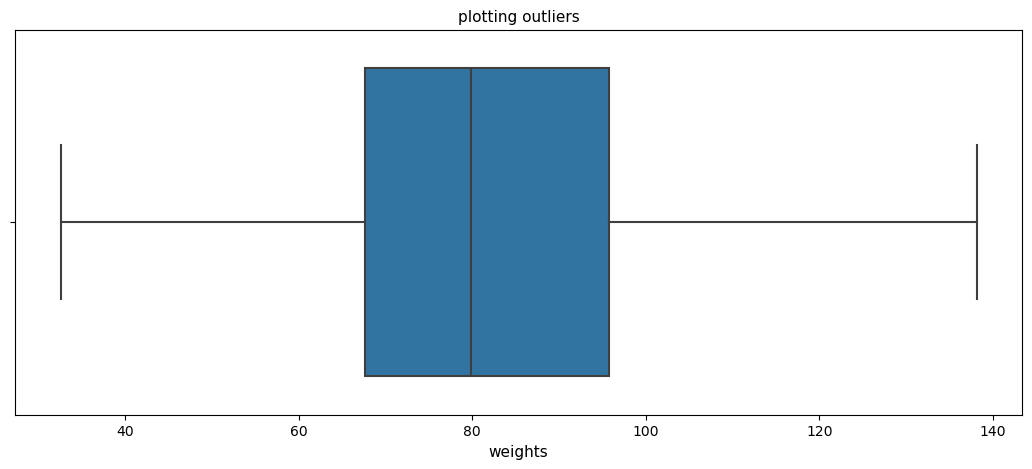

In [38]:
Q1 = df["Weight (kg)"].quantile(0.25)
Q3 = df["Weight (kg)"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Clip and confirm it's saved
df["Weight (kg)"] = df["Weight (kg)"].clip(lower, upper)

# Verify
print("Max after clip:", df["Weight (kg)"].max())  # should be ~138.1
print("Min after clip:", df["Weight (kg)"].min())  # should be ~25.3

# Now plot
plt.figure(figsize=(13,5))
sns.boxplot(x=df["Weight (kg)"])
plt.title("plotting outliers", fontsize=11)
plt.xlabel("weights", fontsize=11)
plt.show()

## imputation 
Imputation in Outliers
Instead of removing or clipping outliers, imputation means replacing outlier values with a statistical value like mean, median, or mode.

Why Impute?

Removing outliers = loses data rows
Clipping = distorts the value (forces it to boundary)
Imputation = replaces with something meaningful, keeps row count intact

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            8388 non-null   int64  
 1   Weight (kg)           8388 non-null   float64
 2   Standing Height (cm)  8388 non-null   float64
 3   BMI(kg/m**2)          8388 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 262.3 KB


In [45]:
df.isnull().sum()

Unnamed: 0              0
Weight (kg)             0
Standing Height (cm)    0
BMI(kg/m**2)            0
dtype: int64

In [46]:
lower,upper

(25.29999999999999, 138.1)

In [52]:
df3.describe()

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
count,8388.000000,8388.000000,8388.000000,8388.000000
mean,4193.500000,83.669218,166.641190,30.034859
std,2421.551362,23.171638,10.079013,7.565376
min,0.000000,32.600000,131.100000,14.200000
25%,2096.750000,67.600000,159.100000,24.900000
50%,4193.500000,79.900000,166.200000,28.800000
75%,6290.250000,95.800000,173.900000,33.800000
max,8387.000000,254.300000,199.600000,92.300000


In [53]:
lower , upper 

(25.29999999999999, 138.1)

In [54]:
median = df3["Weight (kg)"].median()
median

79.9

In [57]:
df3[(df3["Weight (kg)"]<lower)|(df3["Weight (kg)"]>upper)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4


In [64]:
df3.loc[(df3["Weight (kg)"] < lower) | (df3["Weight (kg)"] > upper), "Weight (kg)"] = median

In [65]:
df3[(df3['Weight (kg)'] > lower) | (df3['Weight (kg)'] < upper)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6
...,...,...,...,...
8383,8383,94.3,178.8,29.5
8384,8384,82.8,147.8,37.9
8385,8385,108.8,168.7,38.2
8386,8386,79.5,176.4,25.5


4. Data Transformation
log transformation - log(x)
sqaure root transformation - sqrt(x)
reciprocal transformation - (1/x)
power transformation - BoxCox transformation

4. Data Transformation
log transformation - log(x)
sqaure root transformation - sqrt(x)
reciprocal transformation - (1/x)
power transformation - BoxCox transformation

In [70]:
df.describe()


,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
count,8388.000000,8388.000000,8388.000000,8388.000000
mean,4193.500000,83.669218,166.641190,30.034859
std,2421.551362,23.171638,10.079013,7.565376
min,0.000000,32.600000,131.100000,14.200000
25%,2096.750000,67.600000,159.100000,24.900000
50%,4193.500000,79.900000,166.200000,28.800000
75%,6290.250000,95.800000,173.900000,33.800000
max,8387.000000,254.300000,199.600000,92.300000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            8388 non-null   int64  
 1   Weight (kg)           8388 non-null   float64
 2   Standing Height (cm)  8388 non-null   float64
 3   BMI(kg/m**2)          8388 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 262.3 KB


In [14]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\weightHeight.csv')



## log transformer 


C:\Users\Dhruv stark\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x500 with 0 Axes>

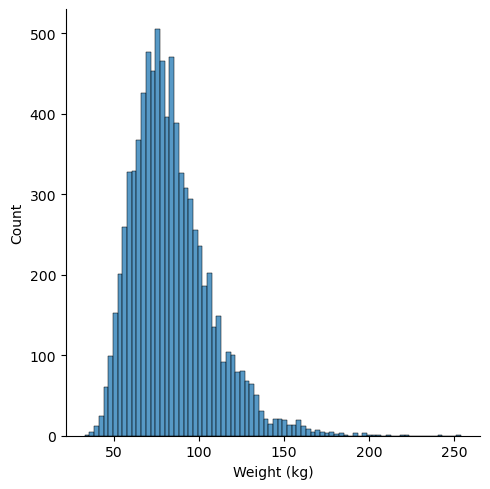

In [15]:


plt.figure(figsize=(10,5))
sns.displot(df["Weight (kg)"])
plt.show()

C:\Users\Dhruv stark\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x500 with 0 Axes>

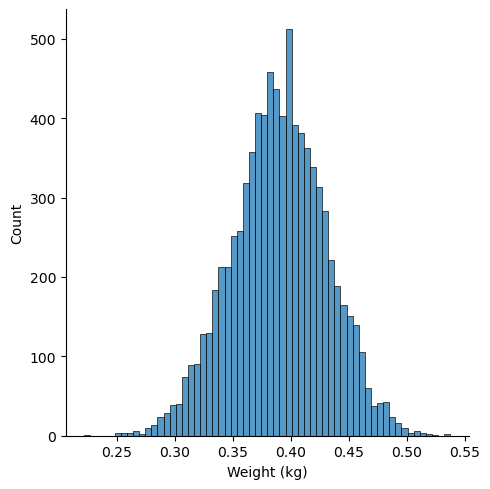

In [18]:
df["Weight (kg)"] = np.log(df["Weight (kg)"])
plt.figure(figsize=(10,5))
sns.displot(df["Weight (kg)"])
plt.show()
